# 01. Exploratory Data Analysis (EDA)


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import get_config

CONFIG = get_config()
RAW_DATA_DIR = PROJECT_ROOT / CONFIG["data"]["raw_data_dir"]

In [2]:
records = []
for split_dir in sorted(RAW_DATA_DIR.iterdir()):
    if not split_dir.is_dir():
        continue
    for emotion_dir in sorted(split_dir.iterdir()):
        if not emotion_dir.is_dir():
            continue
        for image_path in sorted(emotion_dir.iterdir()):
            if not image_path.is_file():
                continue
            records.append({
                "image": image_path.name,
                "image_path": image_path,
                "emotion": emotion_dir.name,
                "split": split_dir.name,
            })

df = pd.DataFrame(records)

In [3]:
df.head()

,image,image_path,emotion,split
0,PrivateTest_10131363.jpg,/home/miguel/git/fer-2013/data/raw/test/angry/...,angry,test
1,PrivateTest_10304478.jpg,/home/miguel/git/fer-2013/data/raw/test/angry/...,angry,test
2,PrivateTest_1054527.jpg,/home/miguel/git/fer-2013/data/raw/test/angry/...,angry,test
3,PrivateTest_10590091.jpg,/home/miguel/git/fer-2013/data/raw/test/angry/...,angry,test
4,PrivateTest_1109992.jpg,/home/miguel/git/fer-2013/data/raw/test/angry/...,angry,test


In [4]:
df['split'].value_counts()

split
train    28709
test      7178
Name: count, dtype: int64

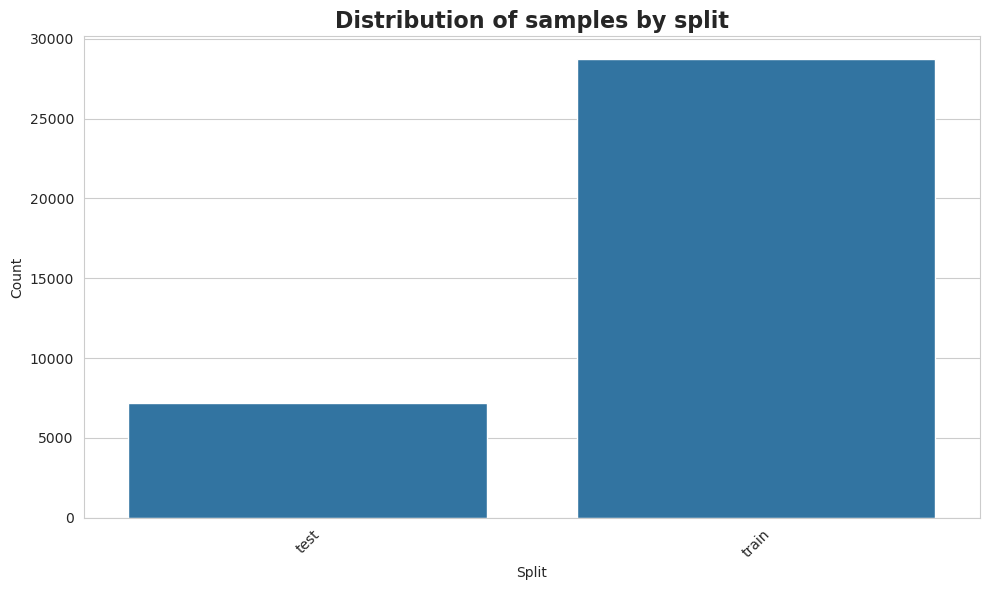

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df,
    x='split',
    ax=ax
)

ax.set_title('Distribution of samples by split', fontsize=16, fontweight='bold')
ax.set_xlabel('Split', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
df.groupby('split')['emotion'].value_counts()

split  emotion 
test   happy       1774
       sad         1247
       neutral     1233
       fear        1024
       angry        958
       surprise     831
       disgust      111
train  happy       7215
       neutral     4965
       sad         4830
       fear        4097
       angry       3995
       surprise    3171
       disgust      436
Name: count, dtype: int64

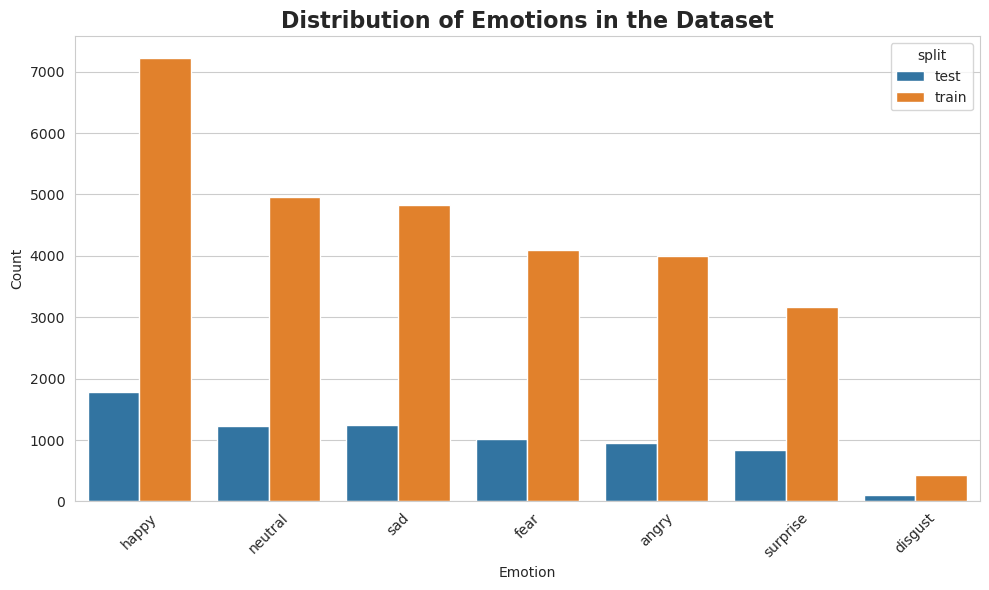

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df,
    x='emotion',
    order=df['emotion'].value_counts().index,
    hue='split',
    ax=ax
)

ax.set_title('Distribution of Emotions in the Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
def plot_images_sample(dataframe: pd.DataFrame, split: str = "train") -> None:
    """Plot one sample image per emotion from the selected split."""
    subset = dataframe[dataframe["split"] == split]
    emotions = sorted(subset["emotion"].unique())

    fig, axes = plt.subplots(1, len(emotions), figsize=(2.8 * len(emotions), 4))
    if len(emotions) == 1:
        axes = [axes]

    for idx, emotion in enumerate(emotions):
        image_path = subset[subset["emotion"] == emotion]["image_path"].iloc[0]
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        axes[idx].imshow(img, cmap="gray")
        axes[idx].set_title(emotion)
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

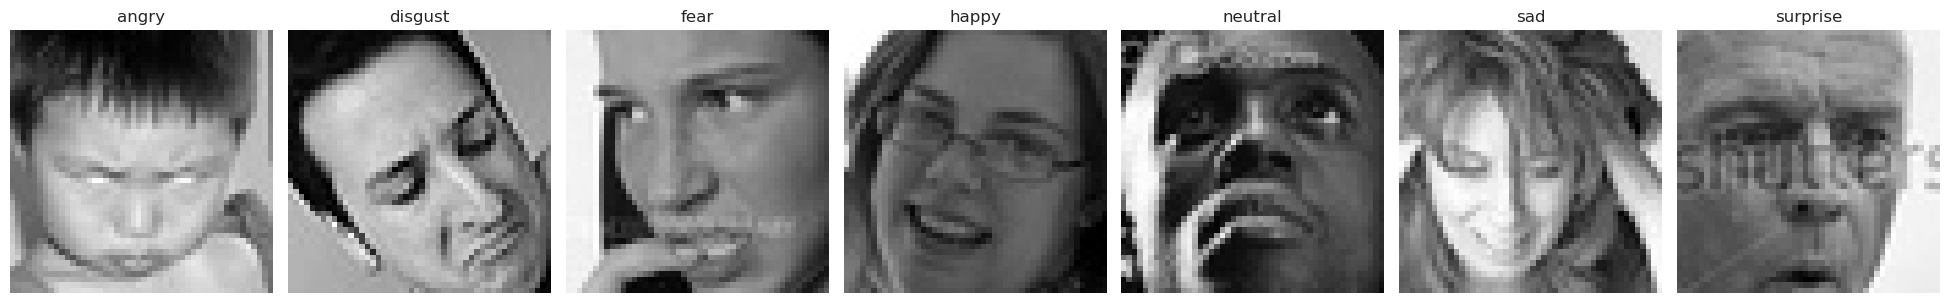

In [9]:
plot_images_sample(df)